<a href="https://colab.research.google.com/github/alessiobsc/AI4Cyber-FaceRecognitionSecurity/blob/main/FGSM_samples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drive Mount and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [2]:
!pip install adversarial-robustness-toolbox # ART libreria per generare e valutare attacchi adversarial
!pip install torch torchvision
!pip install facenet_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 31.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/5

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image

# Import da ART
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import ProjectedGradientDescent
from art.defences.preprocessor import SpatialSmoothing

#Decommentare per forzare python a vedere la versione aggiornata dello script da importare
#import importlib
#importlib.reload(utils) # <--- Questa riga costringe Python a rileggere il file fisico!

# Utility import
utils_path = "/content/drive/MyDrive/Gruppo IA4Cyber"
if utils_path not in sys.path: sys.path.append(utils_path)

from cyber_utils import save_npz_attack, save_npz_attack_safe

# Verifica che la GPU sia disponibile
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


# Prepare test data

In [ ]:
from facenet_pytorch import InceptionResnetV1
#Carica un modello già allenato sul dataset VGGFace2 e lo mette in fase di inferenza
resnet = InceptionResnetV1(pretrained='vggface2').eval()
#modalità classificazione diretta
resnet.classify = True

resnet.to(device)

In [3]:
# Incapsula la rete PyTorch in un classificatore ART.
# Questo wrapper permette ad ART di calcolare gradienti, predizioni
# e attacchi adversarial sul modello NN1. Sono specificati loss,
# ottimizzatore, range dei valori di input, shape delle immagini
# e numero totale di classi VGGFace2.

import torch
from art.estimators.classification import PyTorchClassifier
import torch.optim as optim

# Definizione componenti per ART
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=0.01)

# Creazione del wrapper con device esplicito
classifier = PyTorchClassifier(
    model=resnet,
    clip_values=(-1.0, 1.0),
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 160, 160),
    nb_classes=8631,
    device_type=device.type # Passa 'cuda' o 'cpu' dinamicamente
)

In [4]:
import tensorflow as tf
import pandas as pd

# Caricamento delle etichette (VGGFace2) del classificatore
fpath = tf.keras.utils.get_file('rcmalli_vggface_labels_v2.npy',
                             "https://github.com/rcmalli/keras-vggface/releases/download/v2.0/rcmalli_vggface_labels_v2.npy",
                             cache_subdir="./")
LABELS = np.load(fpath)

path_drive = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Dataset_Selezionato_Progetto/train'

csv_meta_path = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/identity_meta.csv'

try:
    meta_df = pd.read_csv(csv_meta_path, skipinitialspace=True, on_bad_lines='skip')
    meta_df.columns = meta_df.columns.str.strip()
    meta_df['Class_ID'] = meta_df['Class_ID'].astype(str).str.strip().str.replace('"', '').str.replace("'", "")

    # Crea il dizionario che mappa, ad esempio, 'n000156' -> ' Ajda_Pekkan'
    id_to_name = dict(zip(meta_df['Class_ID'], meta_df['Name']))
    print(f"Metadati caricati con successo.")
except Exception as e:
    print(f"Errore caricamento CSV metadati: {e}")
    id_to_name = {}

1346516/1346516 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Metadati caricati con successo.


In [5]:
# Prepara il test set in formato compatibile con ART.
# Ogni immagine viene ridimensionata, convertita in tensore e normalizzata
# nel range [-1, 1]. Le etichette testuali vengono convertite negli indici
# numerici usati dal classificatore VGGFace2.

import numpy as np

# Mapping inverso: Nome Persona -> Indice numerico del modello
name_to_idx = {name.strip().replace("'", ""): i for i, name in enumerate(LABELS)}

x_test_list = []
y_test_list = []

print("Caricamento delle 1000 immagini del test set...")

for folder_name in os.listdir(path_drive):
    folder_path = os.path.join(path_drive, folder_name)
    if not os.path.isdir(folder_path): continue

    real_name = id_to_name.get(folder_name, "").strip().replace("'", "")
    label_idx = name_to_idx.get(real_name, -1)
    if label_idx == -1: continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            # Preprocessing identico alla baseline (78.5%)
            img_pil = Image.open(img_path).convert('RGB').resize((160, 160))
            img_tns = transforms.ToTensor()(img_pil)
            # Normalizzazione [-1, 1] come deciso
            img_tns = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(img_tns)

            x_test_list.append(img_tns.numpy())
            y_test_list.append(label_idx)
        except:
            continue

x_test_all = np.array(x_test_list)
y_test_all = np.array(y_test_list)

print(f"Completato! Dataset pronto: {x_test_all.shape}")

Caricamento delle 1000 immagini del test set...
Completato! Dataset pronto: (1000, 3, 160, 160)


# FGSM Untargeted

## Initialize the attack

=== FASE 1: Grid Search FGSM Untargeted (Solo Metriche) ===
Epsilon= 0.0 | Acc=78.90% | L2=0.0000 | Linf=0.0000
Epsilon=0.01 | Acc=27.10% | L2=2.6929 | Linf=0.0100
Epsilon=0.02 | Acc= 8.60% | L2=5.3743 | Linf=0.0200
Epsilon=0.03 | Acc= 3.90% | L2=8.0467 | Linf=0.0300
Epsilon=0.05 | Acc= 2.40% | L2=13.3616 | Linf=0.0500
Epsilon= 0.1 | Acc= 0.80% | L2=26.4873 | Linf=0.1000
Epsilon=0.15 | Acc= 0.70% | L2=39.3717 | Linf=0.1500
Epsilon= 0.2 | Acc= 0.60% | L2=52.0082 | Linf=0.2000


,Epsilon,Accuratezza,L2,Linf_Real
0,0.00,78.9,0.000000,0.00
1,0.01,27.1,2.692861,0.01
2,0.02,8.6,5.374265,0.02
3,0.03,3.9,8.046663,0.03
4,0.05,2.4,13.361563,0.05
5,0.10,0.8,26.487297,0.10
6,0.15,0.7,39.371719,0.15
7,0.20,0.6,52.008160,0.20


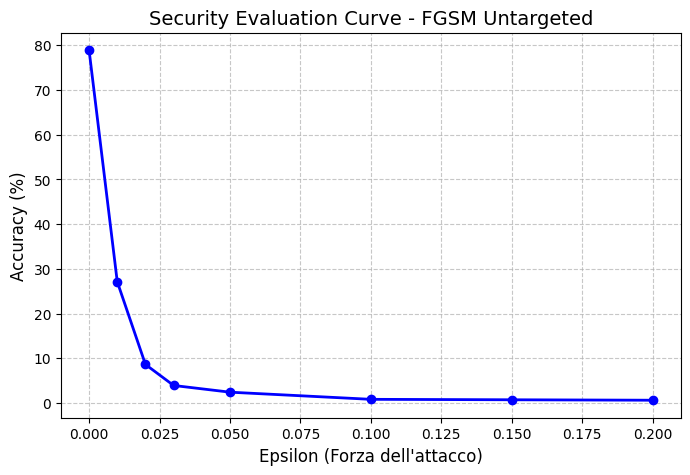

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod

# 1. Parametri per la Grid Search
epsilons = [0.0, 0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2]
untargeted_results = []

print("=== FASE 1: Grid Search FGSM Untargeted (Solo Metriche) ===")

for eps in epsilons:
    if eps == 0.0:
        # Baseline (Immagini Clean)
        preds = np.argmax(classifier.predict(x_test_all, batch_size=128), axis=1)
        acc = np.sum(preds == y_test_all) / len(y_test_all)
        untargeted_results.append({"Epsilon": eps, "Accuratezza": acc*100, "L2": 0.0, "Linf_Real": 0.0})
        print(f"Epsilon={eps:>4} | Acc={acc*100:5.2f}% | L2=0.0000 | Linf=0.0000")
    else:
        # Creazione attacco
        attack_un = FastGradientMethod(estimator=classifier, eps=eps, targeted=False)
        x_adv_un = attack_un.generate(x=x_test_all, batch_size=128)

        # Valutazione accuratezza
        preds_un = np.argmax(classifier.predict(x_adv_un, batch_size=128), axis=1)
        acc_un = np.sum(preds_un == y_test_all) / len(y_test_all)

        # Calcolo distanze per analisi invasività
        diff = (x_adv_un - x_test_all).reshape(len(x_test_all), -1)
        l2_avg = np.mean(np.linalg.norm(diff, ord=2, axis=1))
        linf_avg = np.mean(np.linalg.norm(diff, ord=np.inf, axis=1))

        untargeted_results.append({
            "Epsilon": eps,
            "Accuratezza": acc_un * 100,
            "L2": l2_avg,
            "Linf_Real": linf_avg
        })
        print(f"Epsilon={eps:>4} | Acc={acc_un*100:5.2f}% | L2={l2_avg:.4f} | Linf={linf_avg:.4f}")

# Mostriamo il DataFrame e un grafico per aiutare la scelta
df_untargeted = pd.DataFrame(untargeted_results)
display(df_untargeted)

# Plot Security Evaluation Curve
plt.figure(figsize=(8,5))
plt.plot(df_untargeted["Epsilon"], df_untargeted["Accuratezza"], marker='o', color='blue', linewidth=2)
plt.title("Security Evaluation Curve - FGSM Untargeted", fontsize=14)
plt.xlabel("Epsilon (Forza dell'attacco)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Save samples

In [6]:
from art.attacks.evasion import FastGradientMethod

In [7]:
# === FASE 2: Attacco Finale FGSM e Salvataggio (VERSIONE SICURA) ===
BEST_EPSILON = 0.1 # Inserisci il tuo epsilon ottimo

print(f"Avvio attacco finale con parametro ottimo: eps={BEST_EPSILON}")

# 1. Ricreazione attacco definitivo
final_attack_fgsm = FastGradientMethod(estimator=classifier, eps=BEST_EPSILON, targeted=False)
x_adv_final_fgsm = final_attack_fgsm.generate(x=x_test_all, batch_size=128)

# 2. Calcolo dei logit finali
print("Calcolo delle predizioni finali in corso...")
preds_final_fgsm = classifier.predict(x_adv_final_fgsm, batch_size=128)

# 3. Salvataggio
save_npz_attack_safe(
    attack_family="FGSM",
    attack_mode="untargeted_BEST",
    epsilon=BEST_EPSILON,
    x_adv=x_adv_final_fgsm,
    preds_adv=preds_final_fgsm,
    y_true=y_test_all,
    targeted=False
)

Avvio attacco finale con parametro ottimo: eps=0.1
Calcolo delle predizioni finali in corso...

[utils] Scrittura del file in locale in corso...
[utils] Salvataggio locale completato in: /content/temp_adversarial/FGSM/untargeted_BEST/eps_0_1.npz
[utils] Trasferimento su Google Drive in corso...
[utils] Trovato file precedente. Rimozione in corso per sovrascrittura...
[utils] [✓] TRASFERIMENTO COMPLETATO: /content/drive/MyDrive/Gruppo IA4Cyber/FGSM/untargeted_BEST/eps_0_1.npz


# FGSM Targeted

## Define the target

In [8]:
# Genera adversarial examples con FGSM targeted verso Alessio Cerci.
# Per ogni valore di epsilon, misura l'Attack Success Rate,
# cioè la percentuale di immagini che il modello classifica come Cerci.
# Calcola inoltre la distanza L2 media per valutare l'invasività
# della perturbazione.

# Cerchiamo Alessio Cerci nell'array LABELS usato dal modello
target_name_ricerca = "Alessio_Cerci"
clean_labels = [str(l).strip().replace("'", "").replace('"', '') for l in LABELS]

try:
    real_target_idx = clean_labels.index(target_name_ricerca)
    print(f"L'indice CORRETTO per il modello è: {real_target_idx}")
    print(f"Nome confermato dal modello: {LABELS[real_target_idx]}")
except ValueError:
    # Se non lo trova, cerchiamo chi c'è vicino o con nome simile
    possibili = [i for i, s in enumerate(clean_labels) if "Cerci" in s]
    print(f"Indici che contengono 'Cerci': {possibili}")
    real_target_idx = possibili[0] if possibili else 250 # Fallback

L'indice CORRETTO per il modello è: 235
Nome confermato dal modello:  Alessio_Cerci


## Initialize the attack

=== FASE 1: Grid Search FGSM Targeted (Target:  Alessio_Cerci) ===
Epsilon= 0.0 | ASR= 0.80% | L2=0.0000
Epsilon=0.01 | ASR= 1.50% | L2=2.6929
Epsilon=0.02 | ASR= 4.80% | L2=5.3743
Epsilon=0.03 | ASR= 8.60% | L2=8.0466
Epsilon=0.05 | ASR=15.90% | L2=13.3615
Epsilon= 0.1 | ASR=18.60% | L2=26.4873
Epsilon=0.15 | ASR=16.00% | L2=39.3729
Epsilon= 0.2 | ASR=11.90% | L2=52.0098


,Epsilon,ASR_Targeted (%),L2_Targeted
0,0.00,0.8,0.000000
1,0.01,1.5,2.692884
2,0.02,4.8,5.374284
3,0.03,8.6,8.046598
4,0.05,15.9,13.361526
5,0.10,18.6,26.487316
6,0.15,16.0,39.372898
7,0.20,11.9,52.009804


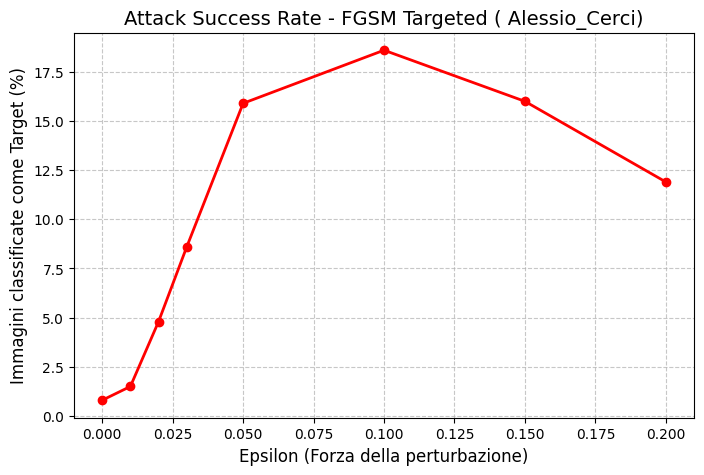

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod

# Parametri per l'attacco mirato
target_idx = real_target_idx
# Lista espansa per un grafico più dettagliato
epsilons = [0.0, 0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2]
y_target_all = np.full(y_test_all.shape, target_idx)

targeted_results = []

print(f"=== FASE 1: Grid Search FGSM Targeted (Target: {LABELS[target_idx]}) ===")

for eps in epsilons:
    if eps == 0.0:
        # Baseline
        preds = np.argmax(classifier.predict(x_test_all, batch_size=128), axis=1)
        asr_base = np.sum(preds == target_idx) / len(y_test_all)
        targeted_results.append({"Epsilon": eps, "ASR_Targeted (%)": asr_base * 100, "L2_Targeted": 0.0})
        print(f"Epsilon={eps:>4} | ASR={asr_base*100:5.2f}% | L2=0.0000")
    else:
        # Creazione attacco mirato (NOTA: targeted=True e passiamo y_target_all)
        attack_tg = FastGradientMethod(estimator=classifier, eps=eps, targeted=True)
        x_adv_tg = attack_tg.generate(x=x_test_all, y=y_target_all, batch_size=128)

        # Calcolo Attack Success Rate (ASR)
        preds_tg = np.argmax(classifier.predict(x_adv_tg, batch_size=128), axis=1)
        asr_tg = np.sum(preds_tg == target_idx) / len(y_test_all)

        # Calcolo Distanza L2
        diff = (x_adv_tg - x_test_all).reshape(len(x_test_all), -1)
        l2_tg = np.mean(np.linalg.norm(diff, ord=2, axis=1))

        targeted_results.append({
            "Epsilon": eps,
            "ASR_Targeted (%)": asr_tg * 100,
            "L2_Targeted": l2_tg
        })
        print(f"Epsilon={eps:>4} | ASR={asr_tg*100:5.2f}% | L2={l2_tg:.4f}")

df_targeted = pd.DataFrame(targeted_results)
display(df_targeted)

# Plot ASR Curve
plt.figure(figsize=(8,5))
plt.plot(df_targeted["Epsilon"], df_targeted["ASR_Targeted (%)"], marker='o', color='red', linewidth=2)
plt.title(f"Attack Success Rate - FGSM Targeted ({LABELS[target_idx]})", fontsize=14)
plt.xlabel("Epsilon (Forza della perturbazione)", fontsize=12)
plt.ylabel("Immagini classificate come Target (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Save samples

In [10]:
# === FASE 2: Attacco Finale FGSM Targeted ===

BEST_EPSILON_TARGETED = 0.1

print(f"Avvio attacco Targeted finale con eps={BEST_EPSILON_TARGETED} verso {LABELS[target_idx]}...")

# 2. Generazione dell'attacco
final_attack_tg = FastGradientMethod(estimator=classifier, eps=BEST_EPSILON_TARGETED, targeted=True)
x_adv_final_tg = final_attack_tg.generate(x=x_test_all, y=y_target_all, batch_size=128)

# 3. Predizioni finali
print("Calcolo delle predizioni finali in corso...")
preds_final_tg = classifier.predict(x_adv_final_tg, batch_size=128)

# 4. Salvataggio sicuro usando utils.py
# Formattiamo il nome del target rimuovendo eventuali spazi per la cartella
target_safe_name = str(LABELS[target_idx]).replace(" ", "_")

save_npz_attack_safe(
    attack_family="FGSM",
    attack_mode=f"targeted_{target_safe_name}",
    epsilon=BEST_EPSILON_TARGETED,
    x_adv=x_adv_final_tg,
    preds_adv=preds_final_tg,
    y_true=y_test_all,
    targeted=True,
    target_idx=target_idx,         # Salviamo l'indice del target
    target_name=LABELS[target_idx] # Salviamo il nome del target
)

Avvio attacco Targeted finale con eps=0.1 verso  Alessio_Cerci...
Calcolo delle predizioni finali in corso...

[utils] Scrittura del file in locale in corso...
[utils] Salvataggio locale completato in: /content/temp_adversarial/FGSM/targeted__Alessio_Cerci/eps_0_1.npz
[utils] Trasferimento su Google Drive in corso...
[utils] [✓] TRASFERIMENTO COMPLETATO: /content/drive/MyDrive/Gruppo IA4Cyber/FGSM/targeted__Alessio_Cerci/eps_0_1.npz
